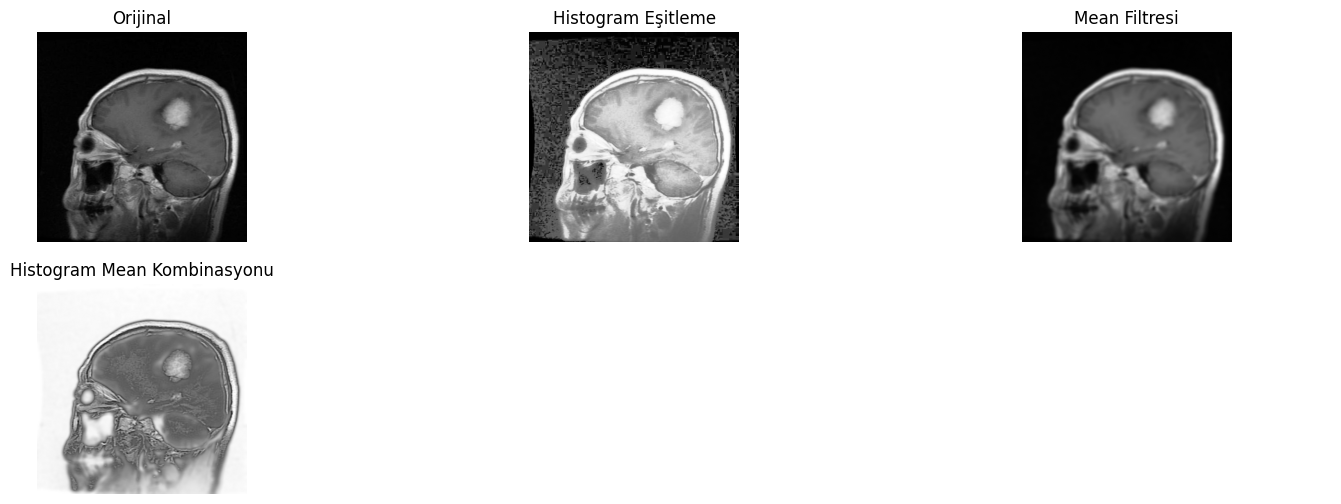

In [9]:
from skimage import exposure, io, filters, img_as_float
from skimage.morphology import disk
from skimage import util
import matplotlib.pyplot as plt
# Orijinal Görüntü
img = io.imread('meningioma.jpg', as_gray=True)

# Histogram eşitleme
hist_image = exposure.equalize_hist(img)
# Mean filtresi
kernel = disk(5) # Komşuluk değeri 
img_ubyte = util.img_as_ubyte(img) # uint float uyarısı için eklendi
meaned_image = filters.rank.mean(img_ubyte, kernel)
# Test filtre
# SORU : Histogram eşitlemesi yapılmış görsel ile mean  filtresi uygulanmış görsele işlemler uygulanırsa ne olur 
test_filter = 255+((meaned_image*hist_image)*(hist_image**8)-meaned_image)

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Orijinal')
axes[0,1].imshow(hist_image, cmap='gray'); axes[0,1].set_title('Histogram Eşitleme')
axes[0,2].imshow(meaned_image,cmap='gray');axes[0,2].set_title('Mean Filtresi')
# Yeni filtre denemesi
axes[1,0].imshow(test_filter,cmap='gray');axes[1,0].set_title('Histogram Mean Kombinasyonu')
# SONUÇ : hastalıklı bölge daha net ortaya çıktı 
for ax in axes.ravel():
    ax.axis('off')

plt.show()

In [2]:
# Projemizde kullanacağımız veri setindeki görüntüler üzerinde çeşitli işlemler yaparak tümörlü bölgelerin daha net ortaya çıkmasını sağlamayı amaçladık 
# Yapmış olduğumuz işlemler : 
# 1) Görüntü skimage kütüphanesi kullanılarak alınmıştır.
# 2) Alınmış olan görüntünün yeni bir hali üzerinde histogram eşitleme filtresi uygulanmıştır.
# 3) Yine orjinal görüntü üzerinden yeni bir görüntü oluşturulmuş ve mean filtresi uygulanmıştır. 
# 4) Elde edilmiş olan 2 yeni görüntü : hist_image, meaned_image olmuştur.
# 5) Daha sonra test amaçlı olarak bu görsel değerleri birbirleriyle çarpılmış,toplanılmış ve kuvveti alınmıştır.
# 6) Bu işlemler denenirken ortaya çıkan sonuçlarda tümörlü bölgenin daha belirgin ortaya çıkması bu yönde ilerlenilmesi için destekleyici olmuştur.
# 7) Deneme yanılma yoluyla farklı farklı kombinasyonlar ile net bir görüntü elde edilmeye çalışılmıştır.
# 8) Belli başlı denemeler yapıldıktan sonra en net sonuç : test_filter = 255+((meaned_image*hist_image)*(hist_image**8)-meaned_image) ile bulunmuştur.
# 9) Oluşturulmuş olan bu yeni görüntüleme sistemi veri seti içerisindeki MENİNGİOMA VE PİTUİTARY sınıfları için tatmin edici sonuçlar vermiş bulunmaktadır.


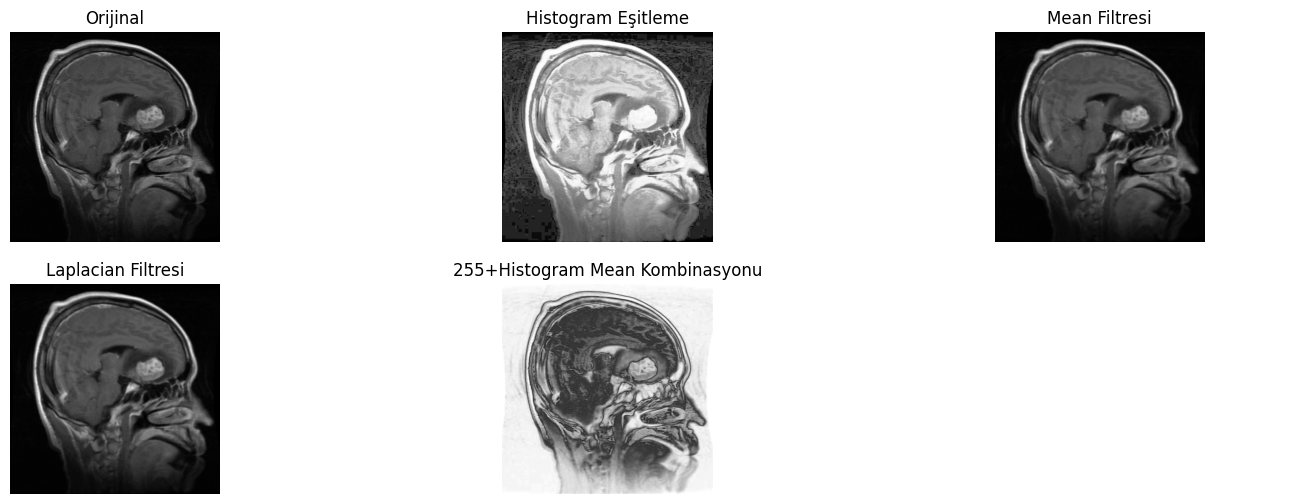

In [53]:
#                        MENİNGİOMA İÇİN NET SONUÇ VERİYOR 
from skimage import exposure, io, filters, img_as_float
from skimage.morphology import disk
from skimage import util
import matplotlib.pyplot as plt
import numpy as np
# Orijinal Görüntü
img = io.imread('meningioma3.jpg', as_gray=True)

# Histogram eşitleme
hist_image = exposure.equalize_hist(img)
# Mean filtresi
kernel = disk(2) # Komşuluk değeri 
img_ubyte = util.img_as_ubyte(img) # uint float uyarısı için eklendi
meaned_image = filters.rank.mean(img_ubyte, kernel)
# Laplacian filtresi
laplacian_image = filters.laplace(img)
# Test filtre
# SORU : Histogram eşitlemesi yapılmış görsel ile mean  filtresi uygulanmış görsele işlemler uygulanırsa ne olur 
test_filter = 255+((meaned_image*hist_image)*(hist_image**5)-meaned_image)+laplacian_image
test_filter = np.clip(test_filter, 0, 255) # değerler 0 - 255 arasında kalsın  

fig, axes = plt.subplots(2, 3, figsize=(18, 6))
axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title('Orijinal')
axes[0,1].imshow(hist_image, cmap='gray'); axes[0,1].set_title('Histogram Eşitleme')
axes[0,2].imshow(meaned_image,cmap='gray');axes[0,2].set_title('Mean Filtresi')
axes[1,0].imshow(meaned_image,cmap='gray');axes[1,0].set_title('Laplacian Filtresi')
# Yeni filtre denemesi
axes[1,1].imshow(test_filter,cmap='gray');axes[1,1].set_title('255+Histogram Mean Kombinasyonu')
# SONUÇ : hastalıklı bölge daha net ortaya çıktı 
for ax in axes.ravel():
    ax.axis('off')

plt.show()

In [ ]:
# 10) Bu aşamada halihazırda oluşturulmuş görüntüleme yöntemine laplace kenar filtresini uygulanmıştır.
# 11) Ancak belirgin bir değişiklik gözlenmemiştir. Bu yüzden filtre:  test_filter = 255+((meaned_image*hist_image)*(hist_image**8)-meaned_image) olarak kullanılmaya devam etmiştir.
# 12) Geliştirilmiş olan görüntüleme yönteminin farklı görseller ile de testi gerçekleştirilmiştir.
# 13) Testler sonucunda ise tümörlü bölge tespitinde %90 oranında kolaylık sağlandığı görülmüştür. 
# 14) Test çıktıları daha rahat görüntülenmesi adına bir sonraki hücrede gösterilmiştir. 

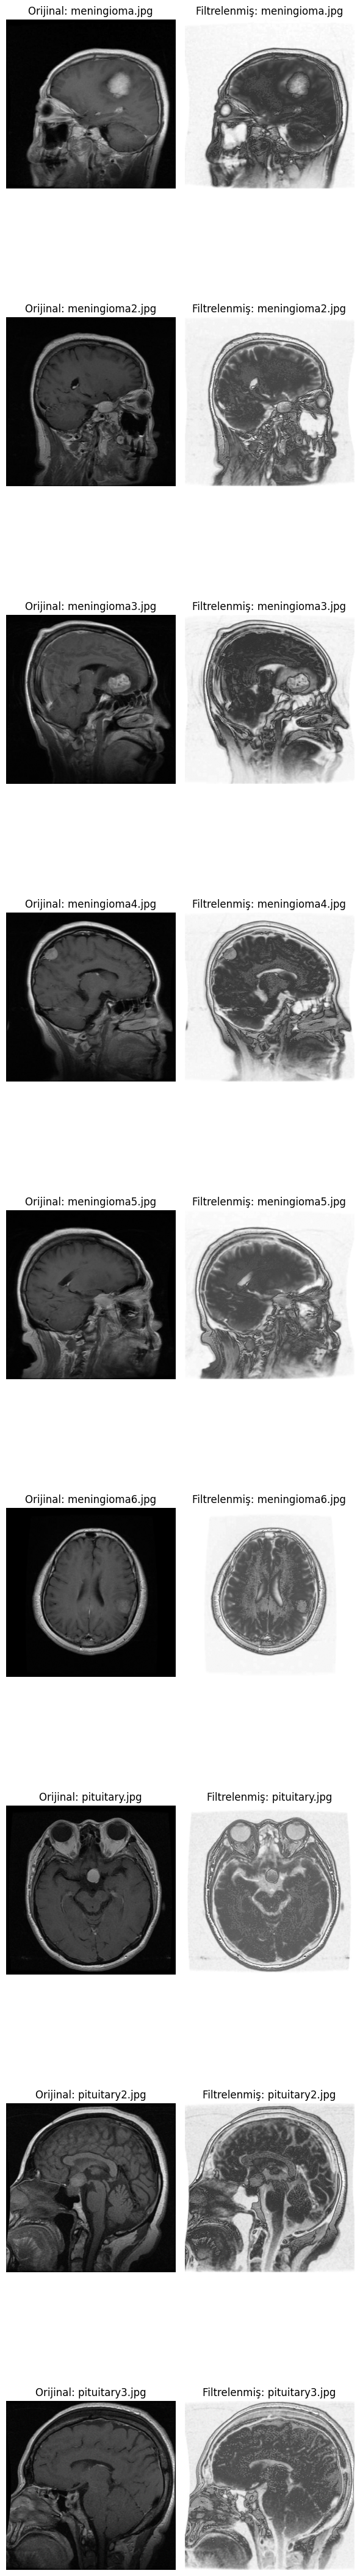

In [63]:
import os
from skimage import exposure, io, filters, util
from skimage.morphology import disk
import matplotlib.pyplot as plt
import numpy as np


def filter_image(img_path):
    img = io.imread(img_path, as_gray=True)
    
    hist_image = exposure.equalize_hist(img)
    
    kernel = disk(2)
    img_ubyte = util.img_as_ubyte(img)
    meaned_image = filters.rank.mean(img_ubyte, kernel)
    test_filter = 255 + ((meaned_image * hist_image) * (hist_image**8) - meaned_image)
    test_filter = np.clip(test_filter, 0, 255)
    
    return img, test_filter

image_files = ['meningioma.jpg', 'meningioma2.jpg', 'meningioma3.jpg','meningioma4.jpg','meningioma5.jpg','meningioma6.jpg','pituitary.jpg','pituitary2.jpg','pituitary3.jpg'] 

n = len(image_files)
fig, axes = plt.subplots(n, 2, figsize=(6, 5 * n)) 

if n == 1: axes = np.expand_dims(axes, axis=0)

for i, file_path in enumerate(image_files):
    try:
        orig, filtered = filter_image(file_path)
        
        axes[i, 0].imshow(orig, cmap='gray')
        axes[i, 0].set_title(f'Orijinal: {file_path}')
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(filtered, cmap='gray')
        axes[i, 1].set_title(f'Filtrelenmiş: {file_path}')
        axes[i, 1].axis('off')

    except Exception as e:
        print(f"{file_path} işlenirken hata oluştu: {e}")

plt.tight_layout()
plt.show()

In [ ]:
# SONUÇ 
# Yapılan çalışmalar ve gözlemler sonucunda ortaya çıkarılan bu yeni görüntüleme yönteminin veri setinde bulunan görsellerin eğitimde kullanılmadan önce 
# filtrelenmesinde kullanılması planlanmaktadır. Henüz bir model eğitiminde kullanılıp test edilmemiş olup ilk testler yapıldıktan sonra kullanılıp kullanılmaycağınaabs
# karar verilecektir. Şayet model eğitimi sonrasında model doğruluk değerlerinin arttığı gözlemlenirse filtre kullanılmaya devam edilecektir. 
